# Train Loss vs Step — Parameter Golf Log Viewer
Load all log files from the `logs/` folder and plot `train_loss` as a function of `step`.

In [2]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Path to logs folder (relative to workspace root)
LOG_DIR = os.path.join("..", "logs")
log_files = sorted(glob.glob(os.path.join(LOG_DIR, "*.txt")))
print(f"Found {len(log_files)} log files:")
for f in log_files:
    print(f"  {os.path.basename(f)}")

Found 9 log files:
  baseline_sp1024.txt
  fullA_8xh100.txt
  fullAttn_test.txt
  fullAttn_test_1h.txt
  fullAttn_test_1h_adamw.txt
  fullAttn_test_1h_compare.txt
  fullAttn_test_1h_muon.txt
  fullAttn_test_1h_smallbatch.txt
  light_baseline.txt


In [5]:
# Parse train_loss lines from each log file
# Format: "step:N/M train_loss:X.XXXX train_time:...ms step_avg:...ms"
pattern = re.compile(r"step:(\d+)/\d+\s+train_loss:([\d.]+)")

all_data: dict[str, pd.DataFrame] = {}
for filepath in log_files:
    name = os.path.splitext(os.path.basename(filepath))[0]
    steps, losses = [], []
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                steps.append(int(m.group(1)))
                losses.append(float(m.group(2)))
    if steps:
        df = pd.DataFrame({"step": steps, "train_loss": losses}).sort_values("step")
        all_data[name] = df
        print(f"{name}: {len(df)} train_loss entries, steps {df['step'].min()}-{df['step'].max()}")
    else:
        print(f"{name}: no train_loss entries found")

baseline_sp1024: 61 train_loss entries, steps 1-8000
fullA_8xh100: 64 train_loss entries, steps 1-10800
fullAttn_test: 12 train_loss entries, steps 1-400
fullAttn_test_1h: 70 train_loss entries, steps 1-2000
fullAttn_test_1h_adamw: 12 train_loss entries, steps 1-400
fullAttn_test_1h_compare: 16 train_loss entries, steps 1-1200
fullAttn_test_1h_muon: 28 train_loss entries, steps 1-1600
fullAttn_test_1h_smallbatch: 25 train_loss entries, steps 1-3000
light_baseline: 12 train_loss entries, steps 1-400


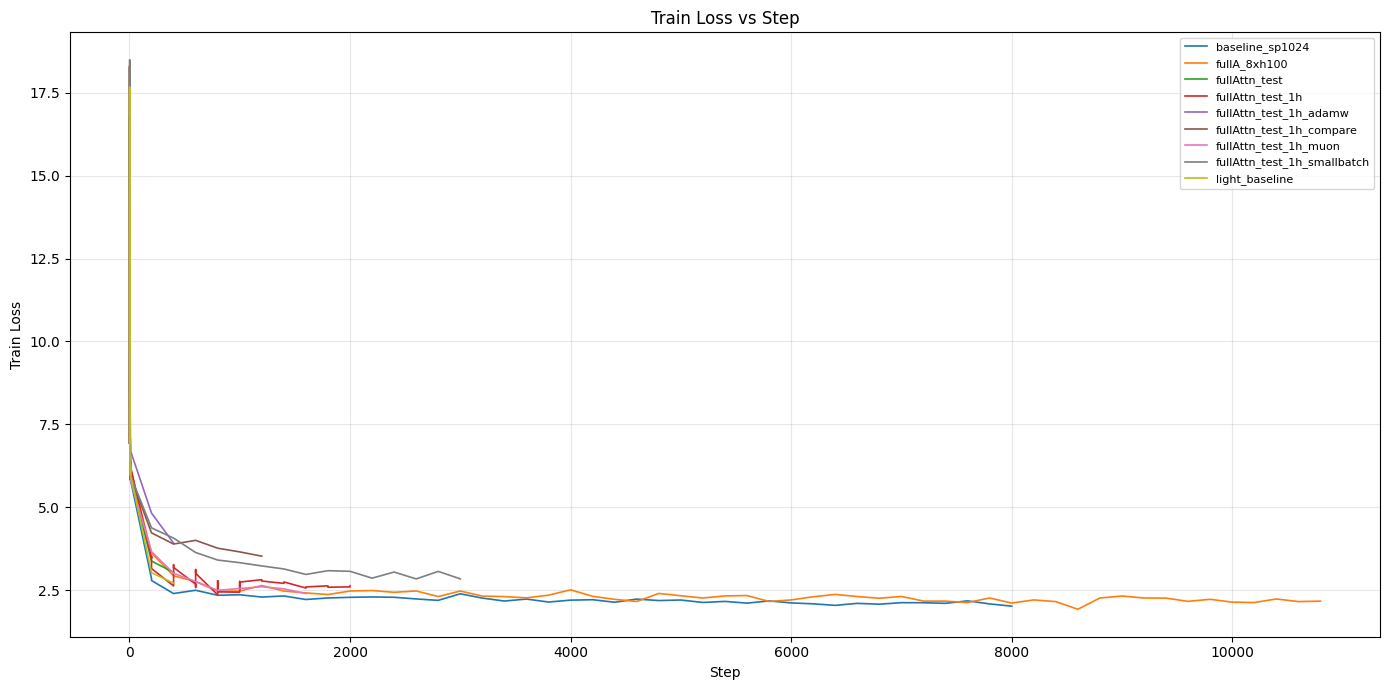

In [6]:
# Plot train_loss vs step for all log files
plt.figure(figsize=(14, 7))
for name, df in all_data.items():
    plt.plot(df["step"], df["train_loss"], label=name, linewidth=1.2)

plt.xlabel("Step")
plt.ylabel("Train Loss")
plt.title("Train Loss vs Step")
plt.legend(fontsize=8, loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()